<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Actividad 19 Resolución**

### **1.Obtención de datos**

In [1]:
import kagglehub

path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:

import pandas as pd
import os

# cargamos el CSV de forma dinámica, usando el path devuelto por kagglehub
# (evita hardcodear rutas que solo funcionan en la máquina del docente)
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
DATA = pd.read_csv(os.path.join(path, csv_file))
DATA.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
DATA.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
DATA.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


En este caso la variable objetivo es 'Survived'

### **2.Transformación**

In [5]:
DATA.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:

from sklearn import preprocessing
le = preprocessing.LabelEncoder()

datak = DATA.copy()

# LabelEncoder convierte columnas de texto en enteros:
# ej: Sex → 'female'=0, 'male'=1  |  Embarked → 'C'=0, 'Q'=1, 'S'=2
# se aplica a todas las columnas de tipo 'object' (texto)
for i in datak.columns:
    if datak[i].dtype == 'object':
        datak[i] = le.fit_transform(datak[i])

datak.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
datak.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Ticket,int64
Fare,float64


In [8]:
datak.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:

# Age tiene valores nulos: los imputamos con la media de la columna
# (estrategia simple; en un análisis completo se evaluarían otras opciones)
datak['Age'] = datak['Age'].fillna(datak['Age'].mean())
datak


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.000000,1,0,523,7.2500,147,2
1,2,1,1,190,0,38.000000,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.000000,0,0,669,7.9250,147,2
3,4,1,1,272,0,35.000000,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.000000,0,0,472,8.0500,147,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,548,1,27.000000,0,0,101,13.0000,147,2
887,888,1,1,303,0,19.000000,0,0,14,30.0000,30,2
888,889,0,3,413,0,29.699118,1,2,675,23.4500,147,2
889,890,1,1,81,1,26.000000,0,0,8,30.0000,60,0


Luego debería hacer un análisis exploratorio

### **3.Preparación de datos**

In [10]:
X=datak.drop('Survived', axis = 1)
y=datak['Survived']

Se debe particionar el conjunto de datos en dos: una parte para entrenar el modelo y otra aprte para testear el mismo.

In [11]:
# se importa la librería
import numpy as np
from sklearn.model_selection import train_test_split

In [12]:
#seteo de semilla
np.random.seed(42)
#generamos para cada uno de los anteriores, conjuntos de datos de entrenamiento(80%) y testeo(20%)
X_train, X_test, y_train, y_test= train_test_split(X, y, train_size= 0.8)


In [13]:
#se observan dimensiones
X_train.shape, X_test.shape

((712, 11), (179, 11))

In [14]:
#se observan dimensiones
y_train.shape, y_test.shape

((712,), (179,))

### **4. Aplicación de Decision Tree y XGBoost**

In [ ]:

import sklearn
from sklearn.tree import DecisionTreeClassifier

# ── Árbol de Decisión ────────────────────────────────────────────────────────
# El árbol de decisión divide el espacio de features en regiones rectangulares.
# Tiende a tener ALTA VARIANZA: pequeños cambios en los datos de entrenamiento
# producen árboles muy distintos (overfitting si no se poda).
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
ypred_test_tree = tree.predict(X_test)


In [16]:
#Medidas de performance
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test_tree))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       105
           1       0.75      0.76      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



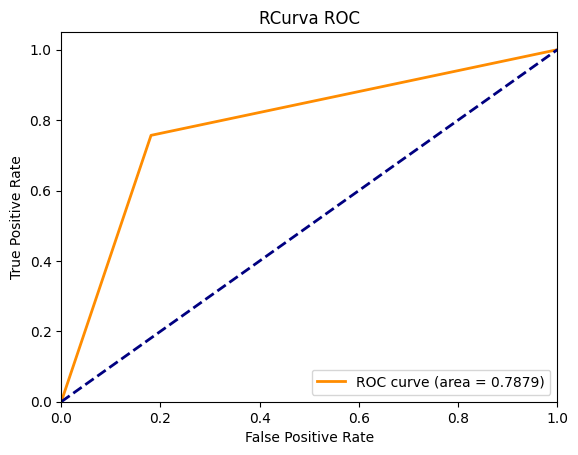

In [17]:
#Obtención de AUC y Curva ROC
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

y_pred_tree = tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_tree)
AUC = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(fpr,tpr,color="darkorange",lw=lw,label="ROC curve (area = %0.4f)" % AUC,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RCurva ROC")
plt.legend(loc="lower right")
plt.show()

In [ ]:

import sklearn
import xgboost as xgb

# ── XGBoost (Extreme Gradient Boosting) ──────────────────────────────────────
# XGBoost es un método de ensamble que entrena árboles en SECUENCIA:
# cada árbol nuevo corrige los errores del anterior (boosting).
# A diferencia del árbol simple, XGBoost:
#   - reduce la VARIANZA al promediar muchos árboles
#   - reduce el BIAS al ajustar iterativamente los residuos
# objective='binary:logistic' → problema de clasificación binaria (survived: 0 o 1)
xgb_1 = xgb.XGBClassifier(objective='binary:logistic')
xgb_1.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
ypred_test_xgb = xgb_1.predict(X_test)

In [20]:
#Medidas de performance
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test_xgb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



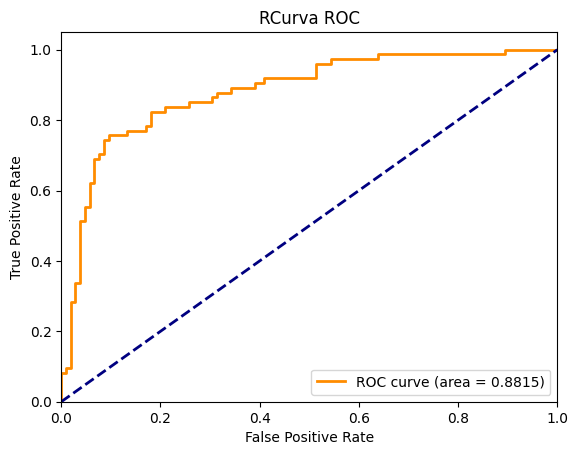

In [21]:
#Obtención de AUC y Curva ROC
from sklearn.metrics import auc
from sklearn.metrics import roc_curve

y_pred_xgb = xgb_1.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)
AUC = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(fpr,tpr,color="darkorange",lw=lw,label="ROC curve (area = %0.4f)" % AUC,
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RCurva ROC")
plt.legend(loc="lower right")
plt.show()

### **5.Análisis de sesgo y varianza**


### ¿Qué es el análisis de sesgo y varianza?

Todo modelo de ML comete errores por tres razones:

$$\text{Error total} \approx \underbrace{\text{Bias}^2}_{\text{sesgo sistemático}} + \underbrace{\text{Varianza}}_{\text{sensibilidad al train}} + \underbrace{\varepsilon}_{\text{ruido irreducible}}$$

- **Bias alto** → el modelo es demasiado simple: no captura la estructura de los datos (*underfitting*).  
- **Varianza alta** → el modelo es demasiado complejo: se adapta demasiado al train y falla en test (*overfitting*).  
- El desafío es encontrar el balance: reducir uno de los dos tiende a aumentar el otro.

`bias_variance_decomp` de `mlxtend` lo calcula entrenando el modelo múltiples veces sobre submuestras distintas del train (bootstrap) y midiendo cuánto varían las predicciones. Con `loss='0-1_loss'` usa la pérdida de clasificación (0 = acierto, 1 = error).

**Interpretación esperada:**
| Modelo | Bias | Varianza | Motivo |
|--------|------|----------|--------|
| Árbol de decisión (sin poda) | bajo | **alto** | El árbol memoriza el train; cualquier cambio produce un árbol diferente |
| XGBoost | bajo | **menor** | Promedia muchos árboles; la varianza individual se cancela parcialmente |


Cálculo de Bias y Variance

In [22]:
!pip install mlxtend

In [23]:
from mlxtend.evaluate import bias_variance_decomp

In [ ]:

# ── Árbol de decisión: descomposición sesgo-varianza ──────────────────────────
# La función entrena el modelo múltiples veces sobre subconjuntos del train
# y mide cuánto varía la predicción en test.
#   avg_expected_loss : error promedio total en test (≈ bias + varianza)
#   avg_bias          : sesgo promedio — cuán lejos está la predicción media del valor real
#   avg_var           : varianza promedio — cuánto varía la predicción entre entrenamientos
avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
    tree,
    X_train.values, y_train.ravel(),   # .values → array numpy; .ravel() → array 1D
    X_test.values,  y_test.ravel(),
    loss='0-1_loss',                   # pérdida de clasificación binaria
    random_seed=42
)

print('Average expected loss: %.3f' % avg_expected_loss)
print('Average bias         : %.3f' % avg_bias)
print('Average variance     : %.3f' % avg_var)


/tmp/ipykernel_95629/1949966110.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(tree, X_train.values, y_train.ravel(), X_test.values, y_test.ravel(),


Average expected loss: 0.239
Average bias: 0.162
Average variance: 0.160


In [ ]:

# ── XGBoost: descomposición sesgo-varianza ────────────────────────────────────
# Misma metodología que para el árbol.
# Se espera que XGBoost tenga menor varianza porque promedia muchos árboles,
# y menor o igual bias porque ajusta los residuos en cada iteración de boosting.
avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
    xgb_1,
    X_train.values, y_train.ravel(),
    X_test.values,  y_test.ravel(),
    loss='0-1_loss',
    random_seed=42
)

print('Average expected loss: %.3f' % avg_expected_loss)
print('Average bias         : %.3f' % avg_bias)
print('Average variance     : %.3f' % avg_var)


/tmp/ipykernel_95629/2379943038.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(xgb_1, X_train.values, y_train.ravel(), X_test.values, y_test.ravel(),


Average expected loss: 0.191
Average bias: 0.168
Average variance: 0.079



**Interpretación del análisis de sesgo y varianza:**

Al comparar los resultados de ambos modelos:

- El **árbol de decisión** (sin poda) tiende a tener **varianza alta**: memoriza el set de entrenamiento y sus predicciones cambian mucho si cambia el train. Este comportamiento es característico del *overfitting*.

- **XGBoost** logra reducir la varianza respecto al árbol, porque en lugar de un solo árbol profundo, combina muchos árboles pequeños. El ruido individual de cada árbol se cancela al promediar. También puede reducir el bias al corregir errores iterativamente (*boosting*).

- El `avg_expected_loss` de XGBoost debería ser menor al del árbol, confirmando que es un modelo más generalizable.

> **Regla práctica:** si un modelo tiene alta varianza pero bajo bias, la solución es agregar más datos o usar ensambles (bagging/boosting). Si tiene alto bias, la solución es usar un modelo más complejo o agregar más features.


### **6. Análisis de equidad**

https://dalex.drwhy.ai/


### ¿Qué es la equidad de un modelo?

Un modelo puede tener buen accuracy global pero ser **sistemáticamente injusto** con ciertos grupos demográficos (género, raza, edad). La librería `dalex` calcula métricas de equidad comparando el comportamiento del modelo entre grupos.

**Variable sensible (protected):** la variable demográfica que define los grupos a comparar. Aquí: `Sex` (Female / Male).  
**Grupo privilegiado (privileged):** el grupo de referencia contra el cual se miden los ratios. Aquí: `Male`.

**Epsilon = 0.8:** umbral de equidad. Para cada métrica se calcula el ratio:

$$\text{ratio} = \frac{\text{métrica}(\text{Female})}{\text{métrica}(\text{Male})}$$

Si el ratio está entre **0.8 y 1.25** (= 1/0.8), el modelo es considerado equitativo para esa métrica (zona verde).  
Si cae fuera de ese rango, hay inequidad (zona roja).

| Métrica | ¿Qué compara? |
|---------|--------------|
| **Statistical Parity** | ¿La tasa de predicción positiva es igual entre grupos? |
| **Equal Opportunity** | ¿El recall (TPR) es igual entre grupos? |
| **Predictive Equality** | ¿La tasa de falsos positivos (FPR) es igual? |
| **Predictive Parity** | ¿La precisión (PPV) es igual? |
| **Accuracy Equality** | ¿El accuracy es igual? |

En el contexto del Titanic, la variable `Survived` tiene sesgo histórico real: las mujeres sobrevivieron a tasas mucho más altas que los hombres ("women and children first"). El análisis de equidad permite cuantificar si el modelo aprendió y reproduce ese sesgo histórico.


In [26]:
!pip install dalex

In [27]:
import dalex as dx

In [ ]:

# dx.Explainer envuelve el modelo entrenado junto con los datos de test y las etiquetas reales.
# Es el objeto base de dalex: a partir de él se calculan todas las métricas de equidad,
# explicabilidad SHAP, importancia de variables, etc.
exp = dx.Explainer(xgb_1, X_test, y_test, verbose=False)


In [ ]:

# ── Definición de variable sensible y grupo de referencia ────────────────────
# 'protected' asigna una etiqueta a cada fila del test set según su género.
# Luego de LabelEncoder: Sex=0 → Female, Sex=1 → Male
protected = np.where(X_test.Sex == 0, 'Female', 'Male')

# 'privileged' es el grupo de referencia:
# todas las métricas se calculan como ratio(Female) / ratio(Male)
# El grupo "privilegiado" histórico en el Titanic fue el masculino
# (paradójicamente, fueron los más perjudicados en supervivencia)
privileged = 'Male'


In [ ]:

# Crea el objeto de equidad: calcula todas las métricas de fairness
# por grupo (Female vs Male) usando las predicciones del modelo sobre X_test
fobject = exp.model_fairness(protected=protected, privileged=privileged)


In [ ]:

# fairness_check imprime un reporte textual con los ratios de cada métrica.
# epsilon=0.8 define el umbral de equidad:
#   - ratio entre 0.8 y 1.25 → equitativo (PASSED)
#   - ratio fuera de ese rango → inequitativo (FAILED)
# Cada ratio = métrica(Female) / métrica(Male)
# ratio < 0.8  → el modelo perjudica a las mujeres en esa métrica
# ratio > 1.25 → el modelo favorece a las mujeres en esa métrica (también es inequidad)
fobject.fairness_check(epsilon=0.8)


Bias detected in 4 metrics: TPR, PPV, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Male'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
             TPR       ACC       PPV       FPR      STP
Female  2.483516  1.007585  1.781316  5.186275  5.23871


In [ ]:

# fobject.plot() genera el gráfico de barras de ratios.
# Cada barra representa una métrica; su altura = ratio Female/Male.
# ZONA VERDE (entre 0.8 y 1.25): el modelo es equitativo en esa métrica.
# ZONA ROJA  (fuera de ese rango): el modelo es inequitativo.
# Las barras más alejadas de 1 indican mayor diferencia de trato entre grupos.
fobject.plot()


/usr/local/lib/python3.12/dist-packages/dalex/fairness/_group_fairness/utils.py:209: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(dropna=False)


Si las barras se encuentran en la zona verde (más cercanas a 1), hay equidad


**Interpretación del análisis de equidad — resultados obtenidos:**

```
             TPR       ACC       PPV       FPR      STP
Female  2.483516  1.007585  1.781316  5.186275  5.23871
```

Cada número es el ratio **métrica(Female) / métrica(Male)**. El rango aceptable es **(0.8 — 1.25)**. Todo lo que quede fuera = zona roja = inequidad.

| Métrica | Valor | Estado | Significado concreto |
|---------|-------|--------|---------------------|
| **TPR** (recall) | 2.48 | ❌ FAIL | El modelo detecta a las mujeres que sobrevivieron 2.48× mejor que a los hombres que sobrevivieron |
| **ACC** (accuracy) | 1.007 | ✅ PASS | El accuracy es prácticamente igual entre géneros (solo 0.7% de diferencia) |
| **PPV** (precisión) | 1.78 | ❌ FAIL | Cuando el modelo predice "mujer sobrevive", acierta 1.78× más que cuando predice "hombre sobrevive" |
| **FPR** | 5.19 | ❌ FAIL | El modelo predice incorrectamente "sobrevivió" para mujeres que murieron 5.19× más veces que para hombres que murieron |
| **STP** (paridad estadística) | 5.24 | ❌ FAIL | El modelo predice "Survived=1" para mujeres 5.24× más frecuentemente que para hombres |

**¿Qué significa en conjunto?**

Es posible observar que en **cuatro medidas** el modelo está siendo injusto o inequitativo según género. Todos los ratios fallidos son > 1 y muy superiores al umbral de 1.25, lo que indica que el modelo está sistemáticamente sesgado hacia predecir "sobrevivió" para mujeres.

**El único que pasa (ACC = 1.007)** tiene sentido: el accuracy global es similar entre géneros porque los errores se compensan — el modelo comete más falsos positivos en mujeres y más falsos negativos en hombres, pero en cantidad total similar.

**¿Por qué ocurre esto?**  
El dataset Titanic tiene un sesgo histórico muy marcado: las mujeres sobrevivieron a tasas mucho más altas que los hombres ("women and children first"). El modelo **aprendió y reprodujo** ese sesgo del pasado.

**¿Es esto un problema ético?**  
En este caso particular, el sesgo *refleja la realidad histórica*, no una discriminación algorítmica injustificada. Sin embargo, si este mismo tipo de modelo se usara en otro contexto (ej: predicción de riesgo crediticio por género), los mismos ratios de 2.5× a 5× serían éticamente inaceptables y habría que corregir el modelo — como hace la teórica aplicando SMOTENC para balancear también por género.

> **Regla práctica:** la equidad no es solo una métrica técnica. Requiere interpretación en contexto. Un modelo técnicamente "inequitativo" puede estar capturando desigualdades reales del mundo; la pregunta ética es si esas desigualdades *deben* o *no deben* reproducirse en las decisiones automatizadas.
